In [ ]:
# This workbook will be flushing out code to read in daily model output files and then compare to weekly deposition files.
#Read in all files in this directory (SO4)
#sum the variables as in other code, and perform conversions
#Read in ntn 2010 SO4 weekly, and perform conversions
#make sure datetime format is the same
#use loop from the CZDP to assign data
#merge and compare concentration outputs with map, timeseries, and correlation.

In [1]:
from tqdm import tqdm
import numpy as np
import datetime as dt
import pandas as pd
from pandas.tseries.offsets import DateOffset
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs                 # For plotting maps
import cartopy.feature as cfeature         # For plotting maps
import numpy as np
from scipy.interpolate import griddata
import datetime
from pathlib import Path
import os
from sklearn.metrics import r2_score


In [2]:
#Define Functions
# Find nearest index
def find_index(array, x):
    if array.ndim == 1:
        idx = np.argmin(np.abs(array - x))
    elif array.ndim == 2:
        idx = np.unravel_index(np.argmin(np.abs(array - x)), array.shape)
    else:
        raise ValueError("Unsupported array dimensions for find_index function.")
    return idx

#abline
def abline(slope, intercept):
    """Plot a line from slope and intercept"""
    axes = plt.gca()
    x_vals = np.array(axes.get_xlim())
    y_vals = intercept + slope * x_vals
    plt.plot(x_vals, y_vals, '--')

In [44]:
#Read in weekly wet deposition chemistry for Jan 2010:
pathData = '/glade/u/home/demurray/External File Uploads'
os.chdir(pathData)
ntn = pd.read_csv('ntn.csv')
so4_nadp = pd.read_csv('NTN-SO4-2010_01-Weekly-conc.csv', parse_dates = ['dateOn', 'dateOff'])

#replace all negative numbers with np.nan and assign units, perform conversions
so4_nadp[so4_nadp.select_dtypes(include='number') < 0] = np.nan
so4_nadp = so4_nadp.rename(columns = {'SO4':'SO4_mgL', 'ppt':'ppt_mm', 'svol':'svol_mL'}) #assign units
so4_nadp['SO4_kgm2_ppt'] = (so4_nadp['SO4_mgL'] * so4_nadp['ppt_mm'])/1000000 #this is scaled to precip volume assuming 1mm = 1L/m2

#Ensure correct datetime formatting
so4_nadp['dateOn'] = pd.to_datetime(so4_nadp['dateOn'], format='%m/%d/%Y %H:%M')
so4_nadp['dateOff'] = pd.to_datetime(so4_nadp['dateOff'], format='%m/%d/%Y %H:%M')
so4_nadp = so4_nadp.sort_values(['siteId', 'dateOn'], ascending = True)

#Need to round date because using DAILY data for modelled comparisons
so4_nadp['dateOnround'] = so4_nadp.dateOn + dt.timedelta(hours=12)
so4_nadp['dateOnround'] = pd.to_datetime(so4_nadp.dateOnround.dt.strftime('%Y-%m-%d'))
so4_nadp['dateOffround'] = so4_nadp.dateOff + dt.timedelta(hours=12)
so4_nadp['dateOffround'] = pd.to_datetime(so4_nadp.dateOffround.dt.strftime('%Y-%m-%d'))

#merge with site info and then select relevant columns
so4_nadp = pd.merge(so4_nadp, ntn, on = 'siteId')
so4_nadp = so4_nadp[['siteId','latitude', 'longitude', 'dateOn', 'dateOff', 'dateOnround', 'dateOffround', 'yrmonth', 'SO4_kgm2_ppt', 'svol_mL','ppt_mm']]

so4_nadp.head(50)

,siteId,latitude,longitude,dateOn,dateOff,dateOnround,dateOffround,yrmonth,SO4_kgm2_ppt,svol_mL,ppt_mm
0,AK01,65.1550,-147.4910,2009-12-29 22:05:00,2010-01-05 22:45:00,2009-12-30,2010-01-06,201001,NaN,0.4,0.000
1,AK01,65.1550,-147.4910,2010-01-05 22:45:00,2010-01-12 20:00:00,2010-01-06,2010-01-13,201001,NaN,4.9,0.000
2,AK01,65.1550,-147.4910,2010-01-12 20:00:00,2010-01-19 21:00:00,2010-01-13,2010-01-20,201001,NaN,0.0,0.508
3,AK01,65.1550,-147.4910,2010-01-19 21:00:00,2010-01-26 21:40:00,2010-01-20,2010-01-27,201001,NaN,0.0,0.000
4,AK01,65.1550,-147.4910,2010-01-26 21:40:00,2010-02-03 01:15:00,2010-01-27,2010-02-03,201001,NaN,0.5,NaN
5,AK02,58.5139,-134.7843,2009-12-29 20:55:00,2010-01-05 20:50:00,2009-12-30,2010-01-06,201001,NaN,168.3,NaN
6,AK02,58.5139,-134.7843,2010-01-05 20:50:00,2010-01-12 22:45:00,2010-01-06,2010-01-13,201001,NaN,3029.0,38.100
7,AK02,58.5139,-134.7843,2010-01-12 22:50:00,2010-01-19 18:15:00,2010-01-13,2010-01-20,201001,NaN,2472.2,25.400
8,AK02,58.5139,-134.7843,2010-01-19 18:20:00,2010-01-26 22:45:00,2010-01-20,2010-01-27,201001,NaN,100.3,0.000
9,AK02,58.5139,-134.7843,2010-01-26 23:20:00,2010-02-02 21:45:00,2010-01-27,2010-02-03,201001,NaN,454.5,NaN


In [63]:
##Assign sampling intervals to NADP deposition data
so4_nadp['SamplingInt'] = pd.Series(dtype='int')
so4_nadp['IntTime'] = pd.Series(dtype='int')

sites = so4_nadp.siteId.unique()

for i in sites:
    so4_nadp.loc[so4_nadp.siteId == i,'SamplingInt'] = list(range(0, len(so4_nadp.loc[so4_nadp.siteId == i]), 1))
    so4_nadp.loc[so4_nadp.siteId == i, 'IntTime'] = so4_nadp.loc[so4_nadp.siteId == i, 'dateOff'] - so4_nadp.loc[so4_nadp.siteId == i, 'dateOn']
so4_nadp.head(50)

,siteId,latitude,longitude,dateOn,dateOff,dateOnround,dateOffround,yrmonth,SO4_kgm2_ppt,svol_mL,ppt_mm,SamplingInt,IntTime
0,AK01,65.1550,-147.4910,2009-12-29 22:05:00,2010-01-05 22:45:00,2009-12-30,2010-01-06,201001,NaN,0.4,0.000,0.0,7 days 00:40:00
1,AK01,65.1550,-147.4910,2010-01-05 22:45:00,2010-01-12 20:00:00,2010-01-06,2010-01-13,201001,NaN,4.9,0.000,1.0,6 days 21:15:00
2,AK01,65.1550,-147.4910,2010-01-12 20:00:00,2010-01-19 21:00:00,2010-01-13,2010-01-20,201001,NaN,0.0,0.508,2.0,7 days 01:00:00
3,AK01,65.1550,-147.4910,2010-01-19 21:00:00,2010-01-26 21:40:00,2010-01-20,2010-01-27,201001,NaN,0.0,0.000,3.0,7 days 00:40:00
4,AK01,65.1550,-147.4910,2010-01-26 21:40:00,2010-02-03 01:15:00,2010-01-27,2010-02-03,201001,NaN,0.5,NaN,4.0,7 days 03:35:00
5,AK02,58.5139,-134.7843,2009-12-29 20:55:00,2010-01-05 20:50:00,2009-12-30,2010-01-06,201001,NaN,168.3,NaN,0.0,6 days 23:55:00
6,AK02,58.5139,-134.7843,2010-01-05 20:50:00,2010-01-12 22:45:00,2010-01-06,2010-01-13,201001,NaN,3029.0,38.100,1.0,7 days 01:55:00
7,AK02,58.5139,-134.7843,2010-01-12 22:50:00,2010-01-19 18:15:00,2010-01-13,2010-01-20,201001,NaN,2472.2,25.400,2.0,6 days 19:25:00
8,AK02,58.5139,-134.7843,2010-01-19 18:20:00,2010-01-26 22:45:00,2010-01-20,2010-01-27,201001,NaN,100.3,0.000,3.0,7 days 04:25:00
9,AK02,58.5139,-134.7843,2010-01-26 23:20:00,2010-02-02 21:45:00,2010-01-27,2010-02-03,201001,NaN,454.5,NaN,4.0,6 days 22:25:00


In [10]:
#Read in daily .nc outputs from the model for Jan 1995
daily_result_dir = Path('/glade/derecho/scratch/demurray/archive/SO4dailyoutput_021624/atm/hist')
daily_so4_files_to_open = "*.nc"
nc_daily_so4 = xr.open_mfdataset(str(daily_result_dir/daily_so4_files_to_open), combine='nested')
nc_daily_so4 #lat = 192, lon = 288, time = 31 (1 month * 31 days = 31)

<xarray.Dataset>
Dimensions:       (lat: 192, lon: 288, lev: 32, ilev: 33, time: 31, nbnd: 2)
Coordinates:
  * lat           (lat) float64 -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon           (lon) float64 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
  * lev           (lev) float64 3.643 7.595 14.36 24.61 ... 957.5 976.3 992.6
  * ilev          (ilev) float64 2.255 5.032 10.16 18.56 ... 967.5 985.1 1e+03
  * time          (time) datetime64[ns] 2010-01-01 2010-01-02 ... 2010-01-31
Dimensions without coordinates: nbnd
Data variables: (12/31)
    gw            (lat) float64 dask.array<chunksize=(192,), meta=np.ndarray>
    hyam          (lev) float64 dask.array<chunksize=(32,), meta=np.ndarray>
    hybm          (lev) float64 dask.array<chunksize=(32,), meta=np.ndarray>
    P0            float64 1e+05
    hyai          (ilev) float64 dask.array<chunksize=(33,), meta=np.ndarray>
    hybi          (ilev) float64 dask.array<chunksize=(33,), meta=np.ndarray>
    ...            ...
    so4_a1SFWET   (time, lat, lon) float32 dask.array<chunksize=(31, 192, 288), meta=np.ndarray>
    so4_a2SFWET   (time, lat, lon) float32 dask.array<chunksize=(31, 192, 288), meta=np.ndarray>
    so4_a3SFWET   (time, lat, lon) float32 dask.array<chunksize=(31, 192, 288), meta=np.ndarray>
    so4_c1SFWET   (time, lat, lon) float32 dask.array<chunksize=(31, 192, 288), meta=np.ndarray>
    so4_c2SFWET   (time, lat, lon) float32 dask.array<chunksize=(31, 192, 288), meta=np.ndarray>
    so4_c3SFWET   (time, lat, lon) float32 dask.array<chunksize=(31, 192, 288), meta=np.ndarray>
Attributes:
    Conventions:       CF-1.0
    source:            CAM
    case:              SO4dailyoutput_021624
    logname:           demurray
    host:              derecho6
    initial_file:      /glade/campaign/cesm/cesmdata/inputdata/atm/cam/inic/f...
    topography_file:   /glade/campaign/cesm/cesmdata/inputdata/atm/cam/topo/f...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  day_1

In [69]:
#Conversions
#Do unit conversions now:
# Select variables from the results_dataset
var_sel_so4 = nc_daily_so4[['so4_a1SFWET', 'so4_a2SFWET', 'so4_a3SFWET', 'so4_c1SFWET',
                              'so4_c2SFWET', 'so4_c3SFWET']]  # extract these variables
#Conversions
conversions = 86400*-1 #seconds to months and Convert to positive values, negative because its a flux TO surface
var_sel_so4 = var_sel_so4.apply(lambda x: x * conversions if x.name in ['so4_a1SFWET', 'so4_a2SFWET', 'so4_a3SFWET', 
                                                                        'so4_c1SFWET', 'so4_c2SFWET', 'so4_c3SFWET'] else x)
#Create new variables to represent the sum of the a's, c's, and total
var_sel_so4['SO4_a_sum'] = var_sel_so4['so4_a1SFWET'] + var_sel_so4['so4_a2SFWET'] + var_sel_so4['so4_a3SFWET']
var_sel_so4['SO4_c_sum'] = var_sel_so4['so4_c1SFWET'] + var_sel_so4['so4_c2SFWET'] + var_sel_so4['so4_c3SFWET']
var_sel_so4['SO4_total'] = var_sel_so4['SO4_a_sum'] + var_sel_so4['SO4_c_sum']
var_sel_so4

<xarray.Dataset>
Dimensions:      (lat: 192, lon: 288, time: 31)
Coordinates:
  * lat          (lat) float64 -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon          (lon) float64 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
  * time         (time) datetime64[ns] 2010-01-01 2010-01-02 ... 2010-01-31
Data variables:
    so4_a1SFWET  (time, lat, lon) float64 dask.array<chunksize=(31, 192, 288), meta=np.ndarray>
    so4_a2SFWET  (time, lat, lon) float64 dask.array<chunksize=(31, 192, 288), meta=np.ndarray>
    so4_a3SFWET  (time, lat, lon) float64 dask.array<chunksize=(31, 192, 288), meta=np.ndarray>
    so4_c1SFWET  (time, lat, lon) float64 dask.array<chunksize=(31, 192, 288), meta=np.ndarray>
    so4_c2SFWET  (time, lat, lon) float64 dask.array<chunksize=(31, 192, 288), meta=np.ndarray>
    so4_c3SFWET  (time, lat, lon) float64 dask.array<chunksize=(31, 192, 288), meta=np.ndarray>
    SO4_a_sum    (time, lat, lon) float64 dask.array<chunksize=(31, 192, 288), meta=np.ndarray>
    SO4_c_sum    (time, lat, lon) float64 dask.array<chunksize=(31, 192, 288), meta=np.ndarray>
    SO4_total    (time, lat, lon) float64 dask.array<chunksize=(31, 192, 288), meta=np.ndarray>

In [70]:
# Only select the cells in .nc that correspond to NADP site lat/long
subset_list = []

for index, row in so4_nadp.iterrows():
    lat = row['latitude']
    lon = 360-(row['longitude']*-1)   # longitude is positive and based on 360 degrees.
    lat_idx = find_index(var_sel_so4['lat'].values, lat)   # right now we are doing a 'find nearest' calculation, should probably interpolate across grid cell and have exact coordinates represented?
    lon_idx = find_index(var_sel_so4['lon'].values, lon)
    subset = var_sel_so4.isel(lat=lat_idx, lon=lon_idx)
    subset['siteId'] = row['siteId']  # Add 'siteId' as a new coordinate/index
    subset = subset.assign_coords(siteId=row['siteId'])
    subset_list.append(subset)

# Concatenate the list of subsets into a new xarray dataset
result_dataset = xr.concat(subset_list, dim='siteId')
result_dataset

#Turn results_dataset xarray into a dataframe with similar attributes
so4_mod_df = result_dataset.to_dataframe().reset_index()
so4_mod_df = so4_mod_df[['siteId', 'time', 'lat', 'lon', 'SO4_total']]
so4_mod_df.head(10)

,siteId,time,lat,lon,SO4_total
0,AK01,2010-01-01,65.497382,212.5,1.395468e-09
1,AK01,2010-01-02,65.497382,212.5,1.415058e-08
2,AK01,2010-01-03,65.497382,212.5,1.780539e-07
3,AK01,2010-01-04,65.497382,212.5,2.826606e-08
4,AK01,2010-01-05,65.497382,212.5,4.990092e-16
5,AK01,2010-01-06,65.497382,212.5,1.233419e-10
6,AK01,2010-01-07,65.497382,212.5,1.388412e-07
7,AK01,2010-01-08,65.497382,212.5,1.233453e-06
8,AK01,2010-01-09,65.497382,212.5,2.814944e-07
9,AK01,2010-01-10,65.497382,212.5,3.412467e-07


In [71]:
#Write loop to assign sampling intervals to  modelled data frame
so4_mod_df['SamplingInt'] = pd.Series(dtype='int') # Add a SamplingInt column to the modelled
sites =so4_nadp.siteId.unique()

for i in tqdm(sites, unit = "sites", total = len(sites), ncols = 100):
    sampleInt = so4_nadp.loc[so4_nadp.siteId==i,'SamplingInt']
    #print(i)
    for j in sampleInt:
       #print(j)
       begDate = pd.Timestamp(so4_nadp.loc[(so4_nadp.siteId == i) & (so4_nadp.SamplingInt == j), 'dateOnround'].item())
       endDate = pd.Timestamp(so4_nadp.loc[(so4_nadp.siteId == i) & (so4_nadp.SamplingInt == j), 'dateOffround'].item())
       #print(endDate)
       so4_mod_df.loc[(so4_mod_df.siteId == i) & (so4_mod_df.time >= begDate) & (so4_mod_df.time < endDate), 'SamplingInt'] = j 

so4_mod_df.drop_duplicates(inplace = True)
so4_mod_df.head(10)

100%|██████████████████████████████████████████████████████████| 245/245 [00:05<00:00, 48.24sites/s]


,siteId,time,lat,lon,SO4_total,SamplingInt
0,AK01,2010-01-01,65.497382,212.5,1.395468e-09,0.0
1,AK01,2010-01-02,65.497382,212.5,1.415058e-08,0.0
2,AK01,2010-01-03,65.497382,212.5,1.780539e-07,0.0
3,AK01,2010-01-04,65.497382,212.5,2.826606e-08,0.0
4,AK01,2010-01-05,65.497382,212.5,4.990092e-16,0.0
5,AK01,2010-01-06,65.497382,212.5,1.233419e-10,1.0
6,AK01,2010-01-07,65.497382,212.5,1.388412e-07,1.0
7,AK01,2010-01-08,65.497382,212.5,1.233453e-06,1.0
8,AK01,2010-01-09,65.497382,212.5,2.814944e-07,1.0
9,AK01,2010-01-10,65.497382,212.5,3.412467e-07,1.0


In [74]:
#After sampling interval has been assigned to model data, group by siteId and sampling interval and sum SO4 total values
so4_mod_sum = so4_mod_df.groupby(['siteId', 'SamplingInt'])['SO4_total'].sum().reset_index()
so4_mod_sum = pd.DataFrame(so4_mod_sum)

#Then merge the resulting dataframe with the nadp weekly samples based on siteId and SamplingInt
so4_nadp_mod = pd.merge(so4_nadp, so4_mod_sum, on = ['siteId', 'SamplingInt'])
so4_nadp_mod = so4_nadp_mod.rename(columns = {'latitude' : 'site_lat', 'longitude' : 'site_lon', 'lat' : 'grid_lat', 
                                             'lon' : 'grid_lon', 'SO4_total': 'SO4_kgm2_mod'})
so4_nadp_mod = so4_nadp_mod.dropna(subset = 'SO4_kgm2_ppt')

so4_nadp_mod['SO4_mgm2_ppt'] = so4_nadp_mod['SO4_kgm2_ppt'] * 1000000 #convert to mg
so4_nadp_mod['SO4_mgm2_mod'] = so4_nadp_mod['SO4_kgm2_mod'] * 1000000
so4_nadp_mod['SO4_percdiff'] = abs(((so4_nadp_mod['SO4_mgm2_mod'] - so4_nadp_mod['SO4_mgm2_ppt']) / so4_nadp_mod['SO4_mgm2_ppt'] )*100)
so4_nadp_mod.head(10)

,siteId,site_lat,site_lon,dateOn,dateOff,dateOnround,dateOffround,yrmonth,SO4_kgm2_ppt,svol_mL,ppt_mm,SamplingInt,IntTime,SO4_kgm2_mod,SO4_mgm2_ppt,SO4_mgm2_mod,SO4_percdiff
12,AK03,63.7232,-148.9676,2010-01-12 23:00:00,2010-01-20 00:30:00,2010-01-13,2010-01-20,201001,6.484620e-07,133.0,5.842,2.0,7 days 01:30:00,3.306520e-06,0.648462,3.306520,409.901863
13,AK03,63.7232,-148.9676,2010-01-20 00:30:00,2010-01-26 21:00:00,2010-01-20,2010-01-27,201001,1.600200e-07,45.4,2.286,3.0,6 days 20:30:00,3.202119e-07,0.160020,0.320212,100.107417
15,AK06,66.9060,-151.6830,2009-12-29 20:00:00,2010-01-05 20:55:00,2009-12-30,2010-01-06,201001,1.229360e-07,72.7,2.794,0.0,7 days 00:55:00,1.189246e-08,0.122936,0.011892,90.326298
20,AK97,58.6794,-156.6664,2009-12-30 20:35:00,2010-01-05 20:15:00,2009-12-31,2010-01-06,201001,7.711440e-07,352.9,8.382,0.0,5 days 23:40:00,3.432332e-07,0.771144,0.343233,55.490386
23,AK97,58.6794,-156.6664,2010-01-19 20:50:00,2010-01-27 00:35:00,2010-01-20,2010-01-27,201001,8.229600e-08,60.5,3.048,3.0,7 days 03:45:00,1.642194e-06,0.082296,1.642194,1895.472188
24,AK97,58.6794,-156.6664,2010-01-27 00:35:00,2010-02-02 22:30:00,2010-01-27,2010-02-03,201001,9.723120e-07,346.7,5.588,4.0,6 days 21:55:00,2.531411e-06,0.972312,2.531411,160.349637
25,AL02,30.7907,-87.8498,2009-12-29 13:15:00,2010-01-05 13:35:00,2009-12-30,2010-01-06,201001,1.631671e-05,966.7,14.478,0.0,7 days 00:20:00,1.890620e-06,16.316706,1.890620,88.412980
28,AL10,32.4583,-87.2422,2010-01-12 19:00:00,2010-01-20 14:30:00,2010-01-13,2010-01-21,201001,8.056880e-06,1131.4,16.510,2.0,7 days 19:30:00,7.708508e-06,8.056880,7.708508,4.323901
31,AL24,30.4746,-88.1411,2009-12-29 15:55:00,2010-01-05 16:15:00,2009-12-30,2010-01-06,201001,1.784350e-05,2070.9,31.750,0.0,7 days 00:20:00,2.264134e-06,17.843500,2.264134,87.311153
32,AL99,34.2886,-85.9699,2009-12-29 14:52:00,2010-01-05 14:44:00,2009-12-30,2010-01-06,201001,2.450084e-06,235.7,3.302,0.0,6 days 23:52:00,3.326849e-06,2.450084,3.326849,35.785106


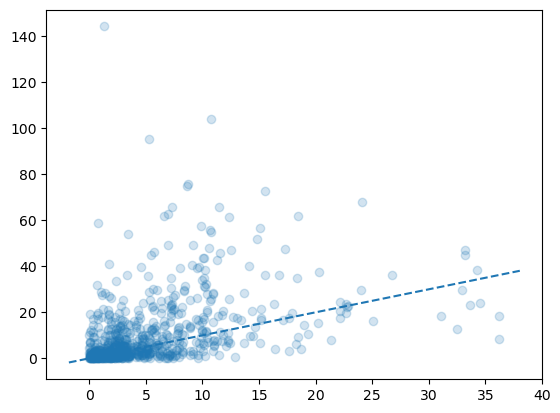

In [85]:
#scatter plot and table of r2, slope
plt.scatter(so4_nadp_mod['SO4_mgm2_mod'], so4_nadp_mod['SO4_mgm2_ppt'], alpha = 0.2)
abline(1,0)
plt.show() 

In [ ]:
#Perform comparisons (timeseries of % difference as well as modelled + observed values) and make a map?

In [ ]:
# calculate chi square